### Conclusion

In this project, a Multiple Linear Regression model was developed to predict medical insurance charges using customer attributes such as age, sex, BMI, number of children, smoking status, and region. The dataset was successfully preprocessed by checking for missing values, encoding categorical variables, and splitting the data into training and testing sets. The trained model achieved a satisfactory performance, demonstrating that factors such as smoking status, age, and BMI have a significant influence on insurance charges. The evaluation metrics and the Actual vs Predicted scatter plot indicate that the model provides reasonably accurate predictions. However, Multiple Linear Regression assumes a linear relationship between variables, which may not fully capture complex real-world patterns. More advanced machine learning algorithms could further improve prediction accuracy.

## Step 9: Conclusion

### Observations

1. The Multiple Linear Regression model achieved a good R² score, indicating that it explains a significant portion of the variation in medical insurance charges.

2. The Actual vs Predicted scatter plot shows that most predicted values follow the trend of the actual charges, although some deviations are present.

3. Prediction errors are higher for certain records, suggesting that additional factors or more advanced regression models could further improve prediction accuracy.

### 8.3 Model Performance Observations

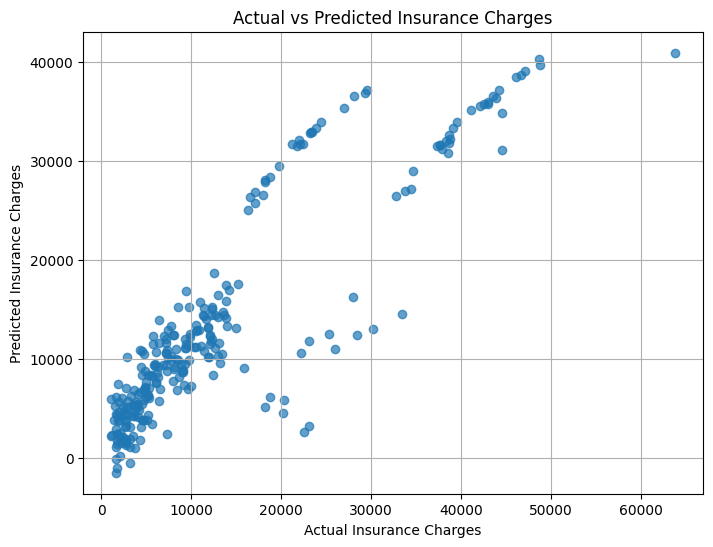

In [18]:
# Scatter plot of Actual vs Predicted values

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")

plt.title("Actual vs Predicted Insurance Charges")

plt.grid(True)

plt.savefig("../images/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

### 8.2 Actual vs Predicted Scatter Plot

In [16]:
# Calculating evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 4186.51
Mean Squared Error (MSE): 33635210.43
R² Score: 0.7833


### 8.1 Evaluate the Model

## Step 8: Model Evaluation

### Observation
The trained Multiple Linear Regression model successfully generated predicted insurance charges for the testing dataset. The comparison between actual and predicted values shows that the model estimates insurance costs reasonably well, although some differences exist due to the limitations of linear regression.

In [15]:
# Displaying first 10 predictions
comparison.head(10).style.format({
    "Actual Charges": "{:.2f}",
    "Predicted Charges": "{:.2f}"
})

,Actual Charges,Predicted Charges
0,9095.07,8924.41
1,5272.18,7116.30
2,29330.98,36909.01
3,9301.89,9507.87
4,33750.29,27013.35
5,4536.26,10790.78
6,2117.34,226.30
7,14210.54,16942.72
8,3732.63,1056.63
9,10264.44,11267.92


In [14]:
# Comparing Actual vs Predicted values
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})

comparison.head(10)

,Actual Charges,Predicted Charges
0,9095.06825,8924.407244
1,5272.17580,7116.295018
2,29330.98315,36909.013521
3,9301.89355,9507.874691
4,33750.29180,27013.350008
5,4536.25900,10790.779562
6,2117.33885,226.298446
7,14210.53595,16942.715999
8,3732.62510,1056.630794
9,10264.44210,11267.919973


In [13]:
# Predicting insurance charges for the testing dataset
y_pred = model.predict(X_test)

### 7.2 Predict Insurance Charges

### Observation

The Multiple Linear Regression model has been successfully trained using the training dataset.

In [12]:
# Training the model using the training dataset
model.fit(X_train, y_train)

LinearRegression()

In [11]:
# Creating the Multiple Linear Regression model
model = LinearRegression()

### 7.1 Build the Multiple Linear Regression Model

## Step 7: Model Development

### Observation

The dataset has been successfully divided into 80% training data and 20% testing data. The training set will be used to train the Multiple Linear Regression model, while the testing set will be used to evaluate its performance.

In [10]:
# Displaying the shape of training and testing datasets

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (1070, 6)
Testing Features : (268, 6)
Training Target  : (1070,)
Testing Target   : (268,)


In [9]:
# Spliting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
# Defining features and target variable

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

### 6.3 Split the Dataset

### Observation

The categorical variables (sex, smoker, and region) have been converted into numerical values using Label Encoding so that they can be used by the Linear Regression model.

In [7]:
# Creating a copy of the dataset
df_encoded = df.copy()

# Initializing Label Encoder
label_encoder = LabelEncoder()

# Encoding categorical columns
categorical_columns = ['sex', 'smoker', 'region']

for column in categorical_columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

# Displaying first five rows of encoded dataset
df_encoded.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


### 6.2 Encode Categorical Variables

### Observation

The dataset contains no missing values. Therefore, no missing data treatment is required before model training.

In [6]:
# Check for missing values

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### 6.1 Check for Missing Values

## Step 6: Data Preprocessing

In [5]:
print("Numerical Features:")

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

numerical_features.remove("charges")

print(numerical_features)

print("\nCategorical Features:")

categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(categorical_features)

print("\nTarget Variable:")

print("charges")

Numerical Features:
['age', 'bmi', 'children']

Categorical Features:
['sex', 'smoker', 'region']

Target Variable:
charges


## Step 5: Identify Features

In [4]:
print("Shape of Dataset:", df.shape)

print("\nInformation:\n")
df.info()

print("\nStatistical Summary:\n")
df.describe()

Shape of Dataset: (1338, 7)

Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Statistical Summary:



,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Step 4: Dataset Information

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Step 3: Display the First Five Records

In [2]:
# Load the dataset

df = pd.read_csv("../data/insurance.csv")

## Step 2: Load the Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assignment 1

# Medical Insurance Cost Prediction using Multiple Linear Regression

## AI/ML Internship

**Name:** Khushie Brahma

**Assignment Number:** Assignment 1

## Objective

The objective of this project is to develop a Multiple Linear Regression model that predicts medical insurance charges based on customer attributes such as age, sex, BMI, number of children, smoking status, and region.